#### Dataset : Fashion MNIST (Keras)

In [ ]:
from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0        # (Dim, Row, Column, Channel) : channel은 흑백 1, 컬러 3

train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size= 0.2,
        random_state=42
    )

#### CNN 모델 생성

In [2]:
model = keras.Sequential()

In [3]:
# 첫번째 합성곱 layer
model.add(
    keras.layers.Conv2D(
        32,                         # filter 개수
        kernel_size= 3,             # 보통 정사각형 구성 (3*3 사이즈로 만든거)
        activation= 'relu',         # 활성화 함수
        padding = 'same',           # same / valid 중 선택
        input_shape = (28, 28, 1)   # input 모양
    )
)

c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##### pooling 층

In [4]:
model.add(
    keras.layers.MaxPooling2D(2)            # 2 * 2 maxpooling 사용
)

##### 두번째 합성곱층 (Optional)

In [5]:
model.add(
    keras.layers.Conv2D(
        64,                         # filter 개수
        kernel_size= 3,             # 보통 정사각형 구성 (3*3 사이즈로 만든거)
        activation= 'relu',         # 활성화 함수
        padding = 'same'            # same / valid 중 선택
    )
)

model.add(
    keras.layers.MaxPooling2D(2)            # 2 * 2 maxpooling 사용
)

##### Dense 층

In [6]:
# 입력층
model.add(
    keras.layers.Flatten()      # input size 모름 -> 그냥 1차원으로 펴버림
)

# 은닉층
model.add(
    keras.layers.Dense(
        100,
        activation= 'relu'
    )
)

# Drop out 층
model.add(
    keras.layers.Dropout(0.5)
)

# 출력층
model.add(
    keras.layers.Dense(
        10,
        activation= 'softmax'
    )
)

In [7]:
# 모델 확인
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │         313,700 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

##### Model Compile

In [8]:
model.compile(
    loss ='sparse_categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint('../Data/best_cnn_model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(
                        patience = 2,
                        restore_best_weights = True
)

#### Trainning

In [9]:
history = model.fit(
                train_scaled,
                train_target,
                epochs = 100,
                validation_data = (val_scaled, val_target),
                callbacks = [checkpoint_cb, early_stopping_cb]
)

Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7908 - loss: 0.5860 - val_accuracy: 0.8685 - val_loss: 0.3603
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8573 - loss: 0.3967 - val_accuracy: 0.8807 - val_loss: 0.3080
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8769 - loss: 0.3420 - val_accuracy: 0.8975 - val_loss: 0.2725
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8914 - loss: 0.3036 - val_accuracy: 0.9039 - val_loss: 0.2595
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9010 - loss: 0.2743 - val_accuracy: 0.9089 - val_loss: 0.2475
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9063 - loss: 0.2540 - val_accuracy: 0.9131 - val_loss: 0.2373
Epoch 7/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9125 - loss: 0.2390 - val_accuracy: 0.9147 - val_loss: 0.2332
Epoch 8/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.

In [10]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9208 - loss: 0.2228


[0.22282564640045166, 0.9208333492279053]

#### 이미지로 확인하기

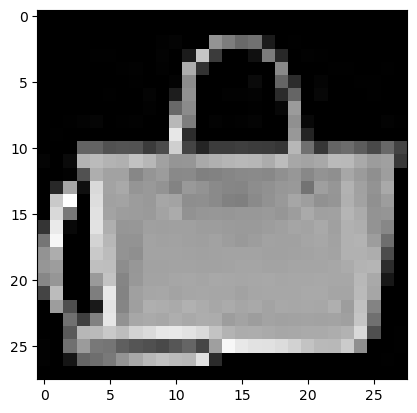

In [11]:
import matplotlib.pyplot as plt

plt.imshow(
    val_scaled[0].reshape(28, 28),
    cmap = 'gray'
)

plt.show()

In [12]:
pred = model.predict(
    val_scaled[:1]
)

pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


array([[1.44827719e-19, 2.51004954e-32, 1.86129482e-24, 1.10768874e-23,
        1.81721320e-25, 3.64595655e-20, 3.40565929e-20, 1.41872335e-24,
        1.00000000e+00, 2.37492709e-24]], dtype=float32)

#### 글자로 변경하기

In [13]:
# 글자로 변경하기
import numpy as np

classes = ['티셔츠', '바지', '스웨터', '드레스', '코트', '샌달', '셔츠', '스니커즈', '가방', '앵글부츠']

In [14]:
classes[np.argmax(pred)]

'가방'